# Algoritmo NAIVE BAYES

# Descripción
Naive Bayes es un clasificador probabilístico basado en el teorema de Bayes, que asume independencia condicional entre los atributos dado el valor de la clase (supuesto "naive"). Es ampliamente usado en clasificación de texto, filtrado de spam, análisis de sentimientos y diagnóstico médico, destacando por su simplicidad, velocidad de entrenamiento y buen desempeño incluso con conjuntos de datos pequeños.
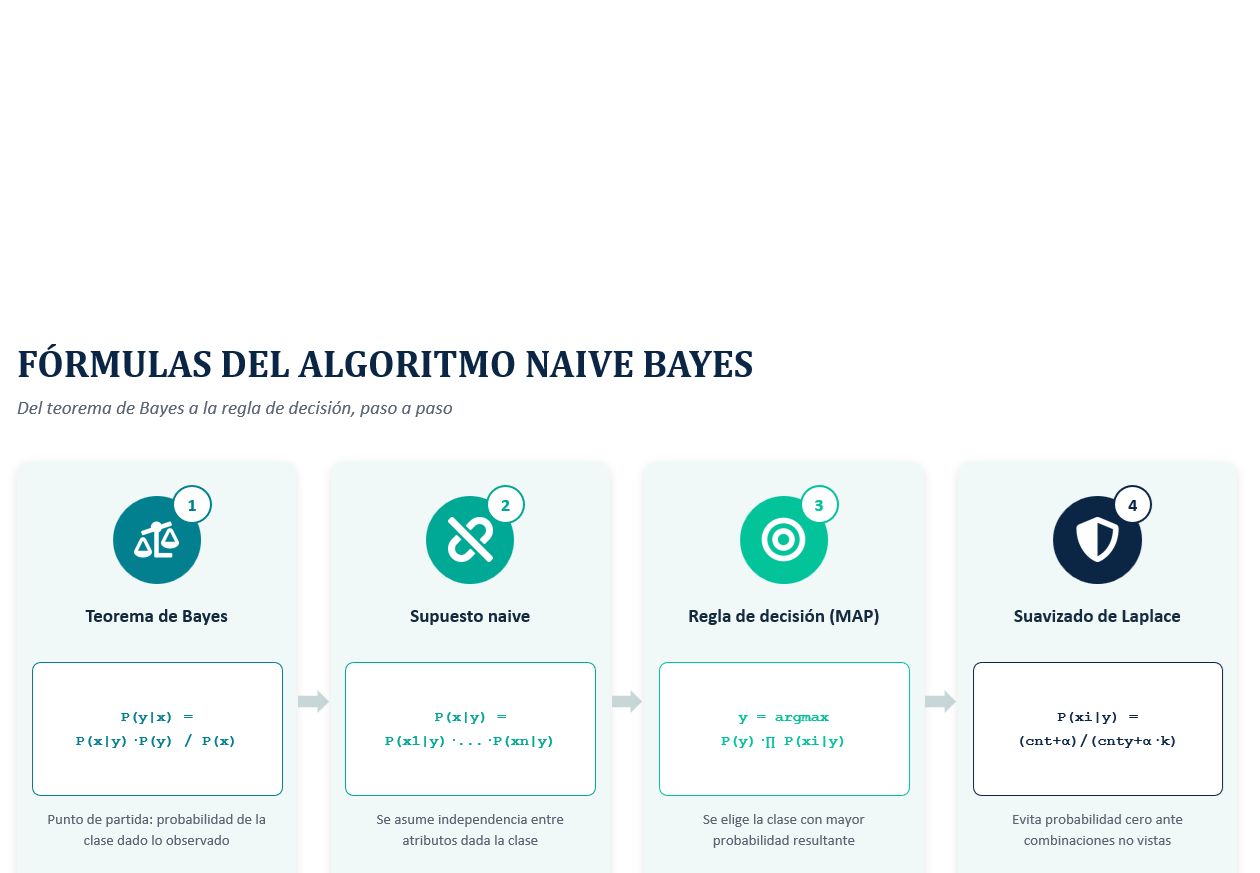

# BIBTEX y Referencias


1.  Rish, I. (2001). An empirical study of the naive Bayes classifier.
2.  IJCAI Workshop on Empirical Methods in Artificial Intelligence.
3.  Zhang, H. (2004). The optimality of naive Bayes. FLAIRS Conference.






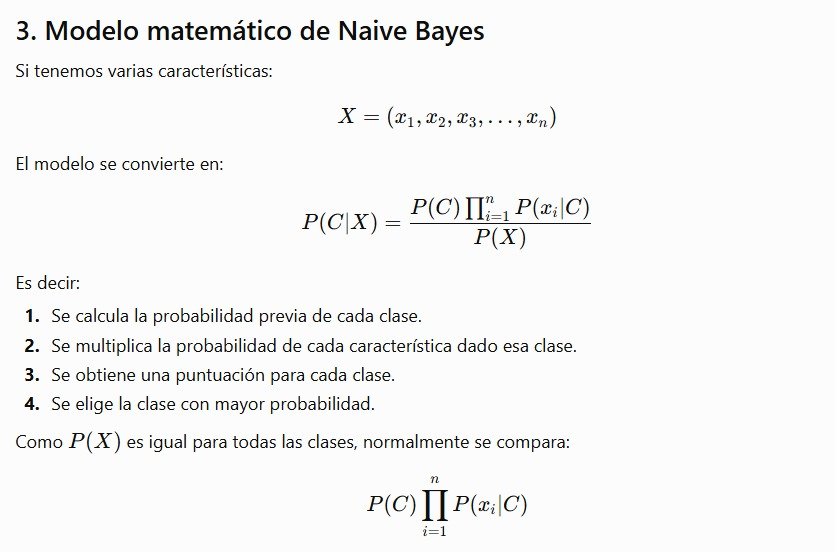# Algoritmo Entrenamiento

Estimación de Máxima Verosimilitud (MLE)
Cálculo de probabilidades a priori P(clase) y verosimilitudes P(atributo | clase) a partir de frecuencias relativas en los datos de entrenamiento
Suavizado de Laplace (Lidstone) para evitar probabilidades nulas

# Tipo de Modelo
Método de aprendizaje --> Supervisado  
Por parámetros --> Paramétrico  
Datos de aprendizaje --> Por lotes (offline / batch)  
Resultado del entrenamiento --> Modelo generativo probabilístico  

# Supuestos y Restricciones
Independencia condicional entre

*   atributos dado el valor de la clase (supuesto "naive", rara vez exacto en la práctica)
*  Las variables continuas deben ajustarse a una distribución supuesta (p. ej. Gaussiana en GaussianNB)
*   Sensible al "problema de frecuencia cero": requiere suavizado cuando una combinación clase-atributo no aparece en el entrenamiento
*   El desempeño se degrada si existen atributos altamente correlacionados entre sí






# Ejemplo

El algoritmo busca la categoría de noticias con la mayor probabilidad:

Donde:

| Símbolo | Descripción |
|----------|-------------|
| **ĉ** | Categoría predicha por el modelo. |
| **C** | Conjunto de categorías posibles. |
| **P(c)** | Probabilidad de la categoría *c*. |
| **xᵢ** | Palabra *i* del documento. |
| **P(xᵢ \| c)** | Probabilidad de la palabra *xᵢ* dada la categoría *c*. |

---

## Datos de entrenamiento

| Categoría | Noticias |
|-----------|----------|
| Deportes | Real Madrid ganó la final |
| Deportes | Barcelona venció al Bayern |
| Tecnología | Apple presentó un nuevo iPhone |
| Tecnología | Google lanzó una nueva IA |
| Política | El presidente anunció nuevas medidas |
| Política | El congreso aprobó la ley |

Nueva noticia:

```text
Microsoft presentó Windows 12
```

---

## Probabilidad de cada categoría

Hay 6 noticias y 2 pertenecen a cada categoría.

P(Deportes) = 2 / 6 = 0.333

P(Tecnología) = 2 / 6 = 0.333

P(Política) = 2 / 6 = 0.333

---

## Aplicar Naive Bayes

Para **Tecnología**:

P(Tecnología) × P(Microsoft | Tecnología) × P(presentó | Tecnología) × P(Windows | Tecnología) × P(12 | Tecnología)

Suponiendo:

| Probabilidad | Valor |
|--------------|------:|
| P(Microsoft \| Tecnología) | 0.08 |
| P(presentó \| Tecnología) | 0.12 |
| P(Windows \| Tecnología) | 0.06 |
| P(12 \| Tecnología) | 0.02 |

El algoritmo realiza el mismo cálculo para **Deportes** y **Política**, y selecciona la categoría con la probabilidad más alta.

---

# Resultado

### Tecnología


In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Noticias de entrenamiento
news = [
    "Real Madrid ganó la final",
    "Barcelona venció al Bayern",
    "Apple presentó un nuevo iPhone",
    "Google lanzó una nueva IA",
    "El presidente anunció nuevas medidas",
    "El congreso aprobó la ley"
]

# Categorías
labels = [
    "Deportes",
    "Deportes",
    "Tecnología",
    "Tecnología",
    "Política",
    "Política"
]

# Convertir texto a números
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(news)

# Entrenar el modelo
model = MultinomialNB()
model.fit(X, labels)

# Nueva noticia
new_news = [
    "Microsoft presentó Windows 12"
]

# Convertir la noticia
X_new = vectorizer.transform(new_news)

# Predicción
prediction = model.predict(X_new)

print("Categoría:", prediction[0])

Categoría: Tecnología


Calcula la probabilidad de que la noticia pertenezca a cada una de las categorías aprendidas por el modelo.

In [ ]:
probabilities = model.predict_proba(X_new)[0]

print(probabilities)

[0.25517241 0.24827586 0.49655172]


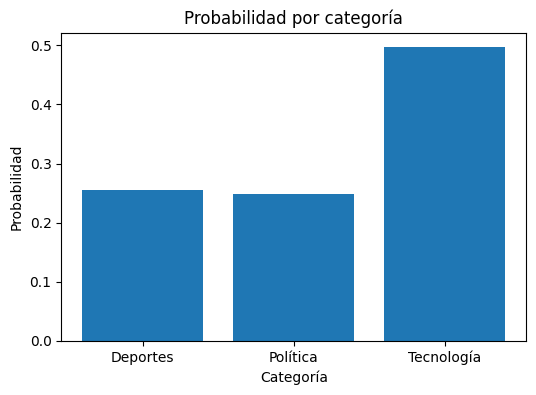

In [ ]:
import matplotlib.pyplot as plt

categories = model.classes_

plt.figure(figsize=(6,4))
plt.bar(categories, probabilities)

plt.title("Probabilidad por categoría")
plt.ylabel("Probabilidad")
plt.xlabel("Categoría")

plt.show()

## Ejemplo 2: Clasificación de Spam


label
ham     4825
spam     747
Name: count, dtype: int64

Precisión: 99.19%


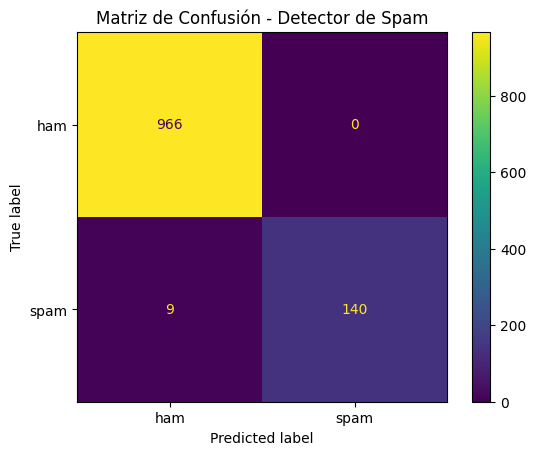

'WINNER!! You have won a FREE prize, call now!' → SPAM
'Hey, are we still meeting for lunch tomorrow?' → HAM


In [ ]:
# ============================================
# Ejemplo 2: Detección de Spam en SMS
# ============================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar dataset real (5,572 SMS etiquetados)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
print(df['label'].value_counts())

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42)

# Vectorizar y entrenar
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB(alpha=1.0)  # alpha=1 → suavizado de Laplace
model.fit(X_train_vec, y_train)

# Evaluar
y_pred = model.predict(X_test_vec)
print(f"\nPrecisión: {accuracy_score(y_test, y_pred):.2%}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de Confusión - Detector de Spam")
plt.show()

# Probar con mensajes nuevos
mensajes = [
    "WINNER!! You have won a FREE prize, call now!",
    "Hey, are we still meeting for lunch tomorrow?"
]
pred = model.predict(vectorizer.transform(mensajes))
for msg, p in zip(mensajes, pred):
    print(f"'{msg}' → {p.upper()}")